# Import libraries and create read , show image

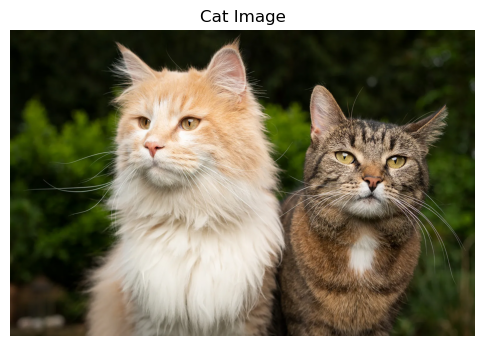

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read the image
img = cv2.imread('cat.jpg')

# Convert BGR (OpenCV) to RGB (Matplotlib)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 5))
plt.imshow(img)
plt.title('Cat Image')
plt.axis("off")
plt.show()

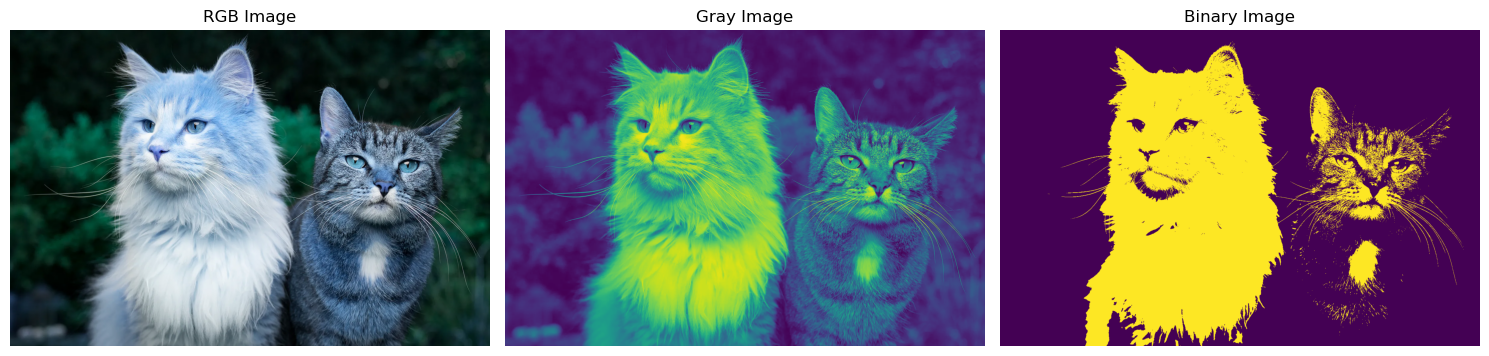

In [5]:
# Question 1 — Read, display and convert RGB to grayscale and binary

rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

binary_img = cv2.threshold(gray_img, 127, 255, cv2.THRESH_BINARY)[1]

plt.figure(figsize=(15,6))

plt.subplot(1,3,1)
plt.imshow(rgb_img)
plt.title("RGB Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(gray_img)
plt.title("Gray Image")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(binary_img)
plt.title("Binary Image")
plt.axis("off")

plt.tight_layout()
plt.show()


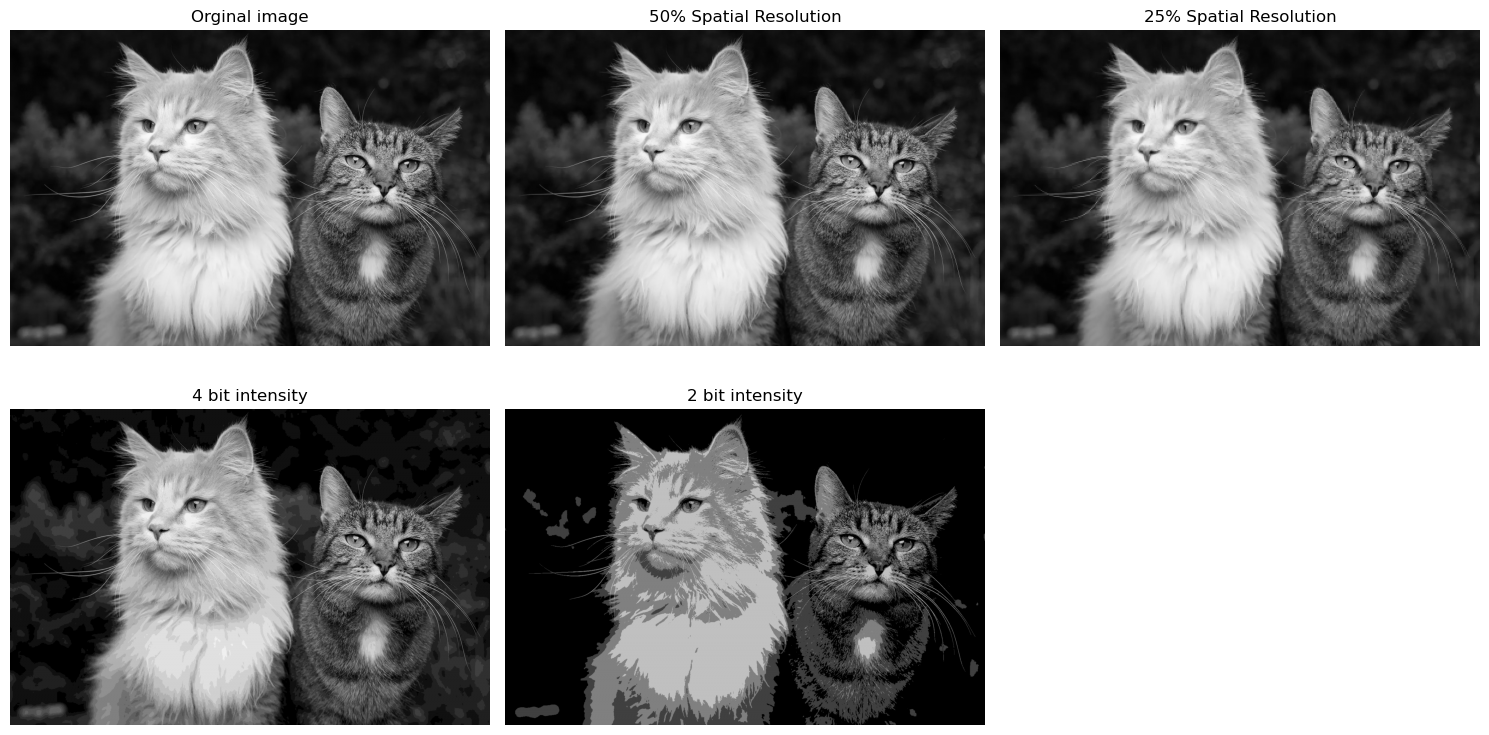

In [8]:
# Question 2 — Change spatial and intensity resolution

# Spatial Resolution Reduction

height, width = gray_img.shape

spatial_50 = cv2.resize(gray_img, (width // 2, height // 2),interpolation=cv2.INTER_AREA)

spatial_25 = cv2.resize(gray_img, (width // 4, height // 4),interpolation=cv2.INTER_AREA)

#Intesity Resolution Reduction

intensity_4bit = (gray_img // 16) * 16
intensity_2bit = (gray_img // 64) * 64

images = [
    gray_img,
    spatial_50,
    spatial_25,
    intensity_4bit,
    intensity_2bit
]

titles = [
    "Orginal image",
    "50% Spatial Resolution",
    "25% Spatial Resolution",
    "4 bit intensity",
    "2 bit intensity"
]

plt.figure(figsize=(15,8))

for i in range(len(images)):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i],cmap="gray",vmin=0,vmax=255)
    plt.title(titles[i])
    plt.axis("off")
plt.tight_layout()
plt.show()


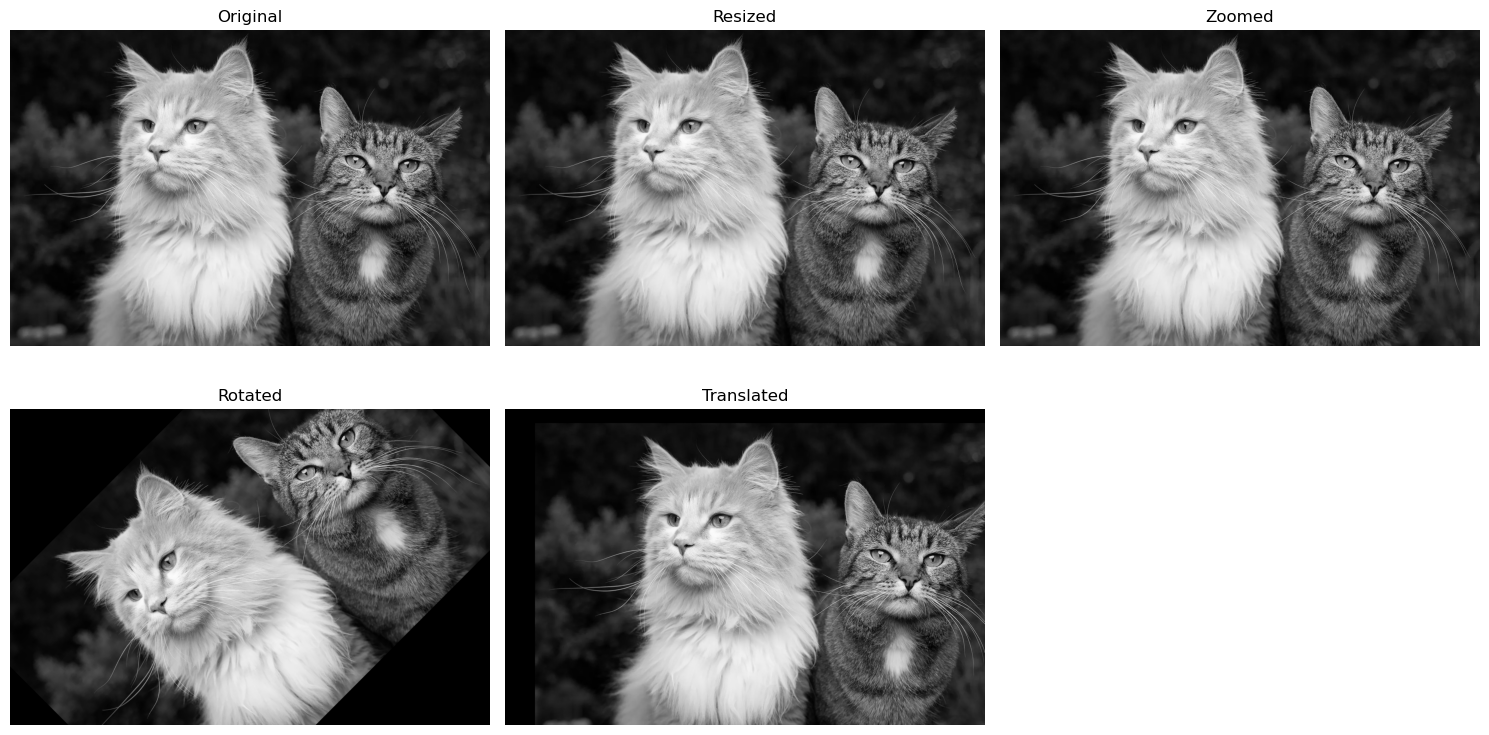

In [10]:
# Question 3 — Resizing, zooming, rotation and translation

height, width = gray_img.shape

#Resize
resized = cv2.resize(gray_img, (width // 2, height // 2),interpolation=cv2.INTER_AREA)

#Zoom
zoomed = cv2.resize(gray_img,None,fx=2,fy=2,interpolation=cv2.INTER_CUBIC)

#Rotate 45 degree
center = (width // 2, height // 2)
rotation_matrix = cv2.getRotationMatrix2D(center, 45, 1.0)
rotated = cv2.warpAffine(gray_img,rotation_matrix,(width, height))

# Translate 100 pixels right and 50 pixels down
translation_matrix = np.float32([
    [1,0,100],
    [0,1,50]
])
translated = cv2.warpAffine(gray_img,translation_matrix,(width, height))

titles = ["Original", "Resized", "Zoomed", "Rotated", "Translated"]
results = [gray_img, resized, zoomed, rotated, translated]

plt.figure(figsize=(15, 8))

for i, result in enumerate(results):
    plt.subplot(2, 3, i + 1)
    plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()